In [ ]:
# Definición de librerías.
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os
import random

In [ ]:
# Conexión con drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [56]:
# Definición de rutas
Ruta_Img = '/content/drive/MyDrive/Proyecto integrador/imagenes/Procesadas'
imagenes_png = [f for f in os.listdir(Ruta_Img) if f.lower().endswith('.png')]

In [83]:
# Seleccionar una imagen al azar
imagen_aleatoria = random.choice(imagenes_png)

# Leer imagen con OpenCV
ruta_completa = os.path.join(Ruta_Img, imagen_aleatoria)
img = cv2.imread(ruta_completa)

In [84]:
# Proceso para zoom de imagen
zoom_factor = 3
threshold = 20
h, w, _ = img.shape
cx, cy = w // 2, h // 2

# Cálculo del centro con base en el zoom deseado
zoom_w = int(w / zoom_factor)
zoom_h = int(h / zoom_factor)
x1 = max(cx - zoom_w // 2, 0)
x2 = min(cx + zoom_w // 2, w)
y1 = max(cy - zoom_h // 2, 0)
y2 = min(cy + zoom_h // 2, h)

img_zoom = img[y1:y2, x1:x2]

In [85]:
# Ajustes de nitidez de la imagena para mejorar la definicipon de la elipse
gray = cv2.cvtColor(img_zoom, cv2.COLOR_RGB2GRAY)
h, w,_ = img_zoom.shape
cx, cy = w // 2, h // 2
_, thresh = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

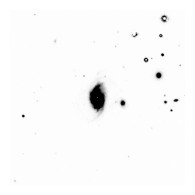

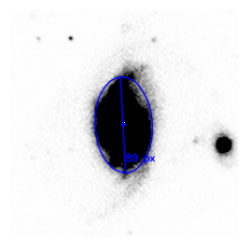

In [86]:
# Seleccionar el contorno más cercano al centro
min_dist = float('inf')
selected_cnt = None

for cnt in contours:
    if len(cnt) >= 5:
        M = cv2.moments(cnt)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
            dist = np.sqrt((cX - cx)**2 + (cY - cy)**2)
            if dist < min_dist:
                min_dist = dist
                selected_cnt = cnt

# Crear copia para dibujar
canvas = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

if selected_cnt is not None:

    # Cálclulo e impresión de elipse
    ellipse = cv2.fitEllipse(selected_cnt)
    (x, y), (MA, ma), angle = ellipse
    cv2.ellipse(canvas, ellipse, (255, 0, 0), 1, cv2.LINE_AA)

    # Cálculo de ejes
    a = MA / 2
    b = ma / 2

    # Cálclulo e impresión de línea
    theta = np.deg2rad(angle)
    pt1 = (int(x - b * np.sin(theta)), int(y + b * np.cos(theta)))
    pt2 = (int(x + b * np.sin(theta)), int(y - b * np.cos(theta)))
    adjusted_ellipse = ((x, y), (MA, ma), angle)
    cv2.line(canvas, pt1, pt2, (255,0,0), 1, cv2.LINE_AA)

    # Impresión de centro
    cv2.circle(canvas, (int(x), int(y)), 2, (255,0,0), -1)

    # Cálculo e impresión de longitud de línea
    line_length_px = int(np.linalg.norm(np.array(pt1) - np.array(pt2)))
    text = f"{line_length_px} px"
    mid_point = (pt2[0], pt2[1] -10)
    cv2.putText(canvas,text,mid_point,cv2.FONT_HERSHEY_SIMPLEX,0.3,(255,0,0),1,cv2.LINE_AA)

plt.figure(figsize=(5, 5))
plt.subplot(2, 1, 1)
plt.imshow(img)
plt.axis('off')
plt.show()

plt.figure(figsize=(5, 5))
plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()